# Phonetic-Convergence Proj

이 프로젝트는 음성수렴 현상을 관찰하기 위한 실험입니다.
분석에 관한 코드 및 실행 결과를 정리한 notebook입니다.

## Module import

In [1]:
import parselmouth
from parselmouth import praat
from parselmouth.praat import call
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
#import librosa
#import librosa.display
import sounddevice as sd
from datetime import datetime
from tqdm import tqdm
import seaborn as sns
import matplotlib.patches as patches
from pathlib import Path
from pprint import pprint

In [2]:
# User define module
from enhanced_formant_analysis import EnhancedFormantAnalyzer
from textgrid_io import TextGridReader
from word_tier_generator import WordTierGenerator

## Hyperparameter

In [3]:
F1_MIN, F1_MAX = 200, 1200    # F1 범위 (Hz)
F2_MIN, F2_MAX = 500, 3000   # F2 범위 (Hz)

In [4]:
# 소스 코드 기준 상대 경로를 이용하여 proj_dir 위치 설정.
proj_dir = os.path.join(Path.home(), 'Documents', 'WorkSpace', 'phoneticConvergence')
exp_data_dir = os.path.join(proj_dir, 'data', 'experiment_data')
print(f"proj_dir: {proj_dir}")
print(f"exp_data_dir: {exp_data_dir}")

proj_dir: /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence
exp_data_dir: /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/data/experiment_data


In [5]:
# wav_dir, annotation_dir 위치 지정.
model_dir = os.path.join(exp_data_dir, 'model_talker')
model_wav_dir = os.path.join(model_dir, 'KFA_audio')
model_annotation_dir = os.path.join(model_dir, 'KFA_annotation_edited')

# 파일 리스트 가져오기. (확장자 고려 필수!)
model_audio_list = [file for file in os.listdir(model_wav_dir) if file.endswith(".wav")]
model_annotation_list = [file for file in os.listdir(model_annotation_dir) if file.endswith(".TextGrid")]
model_audio_list.sort()
model_annotation_list.sort()

# 리스트 확인
print(f"model_audio: {len(model_audio_list)}개")
print(f"model_annotation: {len(model_annotation_list)}개")
pprint(f"model_audio_list: {model_audio_list}")
pprint(f"model_annotation_list: {model_annotation_list}")

model_audio: 50개
model_annotation: 50개
("model_audio_list: ['난색.wav', '난파.wav', '내빈.wav', '내사.wav', "
 "'녹각.wav', '논개.wav', '누룩.wav', '누진.wav', '닌자.wav', "
 "'닝닝.wav', '말미.wav', '망루.wav', '매복.wav', '맹호.wav', "
 "'몰딩.wav', '몽매.wav', '무골.wav', '무운.wav', '미비.wav', "
 "'밀사.wav', '박애.wav', '발탁.wav', '백태.wav', '뱃심.wav', "
 "'복시.wav', '봉독.wav', '분개.wav', '불모.wav', '비재.wav', "
 "'빈축.wav', '상기.wav', '상록.wav', '새참.wav', '샐쭉.wav', "
 "'소조.wav', '송부.wav', '수하.wav', '술책.wav', '시문.wav', "
 "'실족.wav', '파군.wav', '판본.wav', '패물.wav', '팽배.wav', "
 "'포문.wav', '폭압.wav', '품띠.wav', '풍산.wav', '피폭.wav', "
 "'필생.wav']")
("model_annotation_list: ['난색.TextGrid', '난파.TextGrid', "
 "'내빈.TextGrid', '내사.TextGrid', '녹각.TextGrid', '논개.TextGrid', "
 "'누룩.TextGrid', '누진.TextGrid', '닌자.TextGrid', '닝닝.TextGrid', "
 "'말미.TextGrid',

In [6]:
# wav_dir, annotation_dir 위치 지정.
participants_dir = os.path.join(exp_data_dir,'results-KFA-reviewed')
participant_list = [file for file in os.listdir(participants_dir) if file.startswith("participant_LY")]
participant_list.sort()

# 리스트 확인
print(f"participant_list: {len(participant_list)}개")
pprint(f"participant_list: {participant_list}")

participant_list: 52개
("participant_list: ['participant_LY002', 'participant_LY004', "
 "'participant_LY005', 'participant_LY006', 'participant_LY007', "
 "'participant_LY008', 'participant_LY009', 'participant_LY010', "
 "'participant_LY011', 'participant_LY013', 'participant_LY015', "
 "'participant_LY017', 'participant_LY019', 'participant_LY020', "
 "'participant_LY021', 'participant_LY022', 'participant_LY023', "
 "'participant_LY024', 'participant_LY025', 'participant_LY026', "
 "'participant_LY027', 'participant_LY028', 'participant_LY029', "
 "'participant_LY030', 'participant_LY031', 'participant_LY032', "
 "'participant_LY033', 'participant_LY034', 'participant_LY035', "
 "'participant_LY036', 'participant_LY037', 'participant_LY038', "
 "'participant_LY039', 'participant_LY040', 'participant_LY041', "
 "'participant_LY042', 'participant_LY044', 'participant_LY045', "
 "'participant_LY046', 'participant_LY047', 'participant_LY048', "
 "'participant_LY050', 'participant_LY051'

## File Validity Check

### File Naming Check

model speaker의 음성 파일 리스트 naming check.

In [7]:
# any를 사용해서 wav 파일들 중 TextGrid랑 pair가 맞지 않는 경우가 있는지 check.
any([True if wav_file_name.replace('.wav', '.TextGrid') not in model_annotation_list else False for wav_file_name in model_audio_list])

False

participant 폴더에서 각 파일들의 naming check

In [8]:
# 모든 참가자 파일에 wav, annotation 파일이 맞게 존재하는지 확인.
for participant_id in tqdm(participant_list, desc="Checking validity of participant files"):
    participant_dir = os.path.join(participants_dir, participant_id)
    
    participant_wav_list = [file for file in os.listdir(participant_dir) if file.endswith(".wav")]
    participant_annotation_list = [file for file in os.listdir(participant_dir) if file.endswith(".TextGrid")]
    
    participant_wav_list.sort()
    participant_annotation_list.sort()

    # 각 참가자 당 wav 4개, textgrid 4개가 존재해야 하고, 이름이 동일해야 함.
    if len(participant_wav_list) != 4:
        raise FileNotFoundError(f"Not enough wav files in participant_dir: {participant_dir}")
    if len(participant_annotation_list) != 4:
        raise FileNotFoundError(f"Not enough textgrid files in participant_dir: {participant_dir}")
    
    # 각 참가자 당 wav 4개, textgrid 4개가 존재해야 하고, 이름이 동일해야 함.
    if any([True if wav_file_name.replace('.wav', '.TextGrid') not in participant_annotation_list else False for wav_file_name in participant_wav_list]):
        raise FileNotFoundError(f"wav and textgrid files are not paired in participant_dir: {participant_dir}.")

print("All files are paired correctly.")


Checking validity of participant files:   0%|          | 0/52 [00:00<?, ?it/s]

Checking validity of participant files: 100%|██████████| 52/52 [00:00<00:00, 7460.62it/s]

All files are paired correctly.


### Boundary Fixation

In [9]:
# 모든 참가자 textgrid 파일에 boundary fixation.
for participant_id in tqdm(participant_list, desc="Checking validity of participant files"):
    participant_dir = os.path.join(participants_dir, participant_id)
    
    participant_annotation_list = [file for file in os.listdir(participant_dir) if file.endswith(".TextGrid")]
    participant_annotation_list.sort()

    for annotation_file in participant_annotation_list:
        annotation_path = os.path.join(participant_dir, annotation_file)
        # boundary fix
        tg = TextGridReader(annotation_path, fix_boundary_integrity=False, verbose=False)
        tg.boundary_fix(backup=True, inplace=True)

        # redefine Word tier 
        generator = WordTierGenerator(annotation_path, verbose=False)
        generator.add_word_tier_to_textgrid(inplace=True)

    
print("All boundaries of TextGrid files are fixed.")

Checking validity of participant files: 100%|██████████| 52/52 [00:01<00:00, 30.78it/s]

All boundaries of TextGrid files are fixed.


### Word, Phone tier numbering check

textgrid 파일 내의 word, phone tier랑 매칭. phone을 모아서 단어 만들면 그 단어가 word tier에 제대로 존재하는지 check.

뱃심 단어가 문제가 있어 이를 수정.
기존에는 phone tier에 "baedsim"이지만, word_tier에는 "baessim"으로 되어 있어. 모두 "baedsim"으로 통일.

In [76]:
for model_annotation_file in tqdm(model_annotation_list, desc="Checking validity of model speaker files"):
    model_annotation_path = os.path.join(model_annotation_dir, model_annotation_file)
    tg = TextGridReader(model_annotation_path)

    # tier가 2개 인지 check
    if 'phone' not in tg.get_tier_names() or 'word' not in tg.get_tier_names():
        raise TypeError(f"phone or word tier is not found in the TextGrid file.{model_annotation_file}")
    
    # phone tier에서 phone fragment를 추출해서 붙이고, word tier랑 비교.
    phone_fragment = ""
    for interval in tg.get_intervals_by_tier('phone'):
        if interval.text != 'sp':
            phone_fragment += interval.text
    
    word_fragment = ""
    for word_interval in tg.get_intervals_by_tier('word'):
        if word_interval.text != 'sp':
            word_fragment += word_interval.text
    
    if phone_fragment.lower() != word_fragment.lower():
        raise ValueError(f"phones and word are not matched in the TextGrid file.{model_annotation_file}")

print("The word and phone tiers in all model speaker files are matched correctly.")


Checking validity of model speaker files: 100%|██████████| 50/50 [00:00<00:00, 2508.02it/s]

The word and phone tiers in all model speaker files are matched correctly.


참가자 파일도 마찬가지로 check
하다가보면, phone_tier 같은데에서 phone 끝에 spacebar 들어간 경우가 종종 있으니 확인 요망.
-> word tier와 phone tier 간 오탈자 체크

In [ ]:
# 모든 참가자의 textgrid에서 phone, word tier에서 phone 조각들이 제대로 되어 있나 check.
for participant_id in tqdm(participant_list, desc="Checking validity of participant files"):
    participant_dir = os.path.join(participants_dir, participant_id)
    
    participant_annotation_list = [file for file in os.listdir(participant_dir) if file.endswith(".TextGrid")]
    participant_annotation_list.sort()

    for participant_annotation_file in participant_annotation_list:
        participant_annotation_path = os.path.join(participant_dir, participant_annotation_file)
        tg = TextGridReader(participant_annotation_path)

        if 'phone' not in tg.get_tier_names() or 'word' not in tg.get_tier_names():
            raise TypeError(f"phone or word tier is not found in the TextGrid file.{participant_annotation_file}")

        phone_fragment_Q = []
        phone_fragment = ""
        for interval in tg.get_intervals_by_tier('phone'):
            if interval.text != 'sp':
                phone_fragment += interval.text
            elif interval.text == 'sp' and phone_fragment != "":
                phone_fragment_Q.append(phone_fragment)
                phone_fragment_Q.append("sp")
                phone_fragment = ""
            else:
                phone_fragment_Q.append("sp")
                phone_fragment = ""
        # remainder: sp가 나와야 그 전까지 단어 처리하고 리스트에 추가할 수 있는데, textgrid 마지막에 sp 없이 끝나는 경우.
        if phone_fragment != "":
            phone_fragment_Q.append(phone_fragment)
        
        phone_fragment_df = pd.DataFrame(phone_fragment_Q, columns=['text'])
        phone_fragment_df = phone_fragment_df[phone_fragment_df['text'] != 'sp'].reset_index(drop=True)

        word_df = pd.DataFrame(tg.get_intervals_by_tier('word'))
        word_df = word_df[word_df['text'] != 'sp'].reset_index(drop=True)
        
        if phone_fragment_df.shape[0] != word_df.shape[0]:
            print(f"phones and word are not matched in the TextGrid file.{participant_annotation_file}")
            print(f"phone_fragment_df.shape[0]: {phone_fragment_df.shape[0]}")
            print(f"word_df.shape[0]: {word_df.shape[0]}")

            print(phone_fragment_df['text'].value_counts())
            print(word_df['text'].value_counts())
            raise ValueError(f"phones and word are not matched in the TextGrid file.{participant_annotation_file}")
        else:
            pass
            #print(f"phones and word are matched in the TextGrid file.{participant_annotation_file}")

                
print("All files are paired correctly.")

Checking validity of participant files: 100%|██████████| 4/4 [00:00<00:00, 30.84it/s]

All files are paired correctly.


In [10]:
def checker(participant_id: str, tg_name: str, text: str):
    participant_dir = os.path.join(participants_dir, participant_id)
    participant_annotation_dir = os.path.join(participant_dir, tg_name)
    tg = TextGridReader(participant_annotation_dir)
    pprint(tg.find_intervals_by_text(tier_name='word', text=text))

checker("participant_LY025", "25_stage6_20250407_1938.TextGrid", "sojo")
        

[Interval(xmin=75.34821151263068,
          xmax=75.84884201115933,
          text='sojo',
          interval_number=86)]


그렇다면 단어의 개수는 맞을까? 참가자들이 정말 모든 단어가 제시된거에 맞게 다 발화했을까?
개수가 맞지 않는 참가자들이 어떠한 단어를 몇개 발화했는지 다 체크해보자.

In [58]:
# 모든 참가자의 textgrid에서 phone, word tier에서 phone 조각들이 제대로 되어 있나 check.
for participant_id in tqdm(participant_list, desc="Checking validity of participant files"):
    participant_dir = os.path.join(participants_dir, participant_id)
    
    participant_annotation_list = [file for file in os.listdir(participant_dir) if file.endswith(".TextGrid")]
    participant_annotation_list.sort()

    for participant_annotation_file in participant_annotation_list:

        #excepted_list = ['25_', '26_', '42_']
        excepted_list = []
        if any(excepted_list in participant_annotation_file for excepted_list in excepted_list):
            continue

        participant_annotation_path = os.path.join(participant_dir, participant_annotation_file)
        tg = TextGridReader(participant_annotation_path)
        
        word_df = pd.DataFrame(tg.get_intervals_by_tier('word'))
        word_df = word_df[word_df['text'] != 'sp'].reset_index(drop=True)

        if 'stage2' in participant_annotation_file or 'stage6' in participant_annotation_file:
            correct_total_word_num = 50
            correct_word_repeated_num = 1
        elif 'stage4' in participant_annotation_file or 'stage5' in participant_annotation_file:
            correct_total_word_num = 150
            correct_word_repeated_num = 3
        else:
            raise ValueError(f"stage number is not valid. TextGrid file: {participant_annotation_file}")

        word_count_df = pd.DataFrame({
            'word': word_df['text'].value_counts().index,
            'count': word_df['text'].value_counts().values
        })

        if word_df.shape[0] != correct_total_word_num:
            print(f"missing word in the TextGrid file.{participant_annotation_file}")
            print(f"expected word stimuli number: {correct_total_word_num}")
            print(f"current word count: {word_df.shape[0]}")
            if word_count_df[word_count_df['count'] != correct_word_repeated_num].shape[0] > 0:
                print(word_count_df[word_count_df['count'] != correct_word_repeated_num])
            else:
                print(word_count_df)
            #raise ValueError(f"missing word in the TextGrid file.{participant_annotation_file}")
        else:
            pass
            #print(f"word tier is matched in the TextGrid file.{participant_annotation_file}")
    
#print("All files are paired correctly.")

Checking validity of participant files:  54%|█████▍    | 28/52 [00:00<00:00, 52.51it/s]

missing word in the TextGrid file.25_stage5_20250407_1930.TextGrid
expected word stimuli number: 150
current word count: 142
      word  count
42  siljog      2
43    muun      2
44     sua      2
45  paemul      2
46   pipog      2
47  songbu      2
48  maebog      2
49   pogab      2


Checking validity of participant files: 100%|██████████| 52/52 [00:00<00:00, 55.28it/s]


일단 25번 참가자의 경우에는 5stage 에서 missing이 너무 많아서 분석할 수 없음. 발화가 녹음되지 않음.
26번은 5, 42번의 5는 추가 분절 필요.

25-08-16: boundary-fix -> word_counting까지 함.

## Formant Analysis

### Processing

#### model-speaker

In [10]:
import parselmouth
from parselmouth import praat
from parselmouth.praat import call
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
#import librosa
#import librosa.display
import sounddevice as sd
from datetime import datetime
from tqdm import tqdm
import seaborn as sns
import matplotlib.patches as patches
from pathlib import Path
from pprint import pprint
from enhanced_formant_analysis import EnhancedFormantAnalyzer, logger
# model_audio
def demo_usage():
    """
    Demonstration of the enhanced formant analyzer usage.
    This demo now automatically finds and analyzes all vowels in the specified files.
    """
    print("Enhanced Formant Analyzer Demo")
    print("=" * 40)
    
    # --- Configuration ---
    # Adjust these paths to your actual data directories
    proj_dir = os.path.join(Path.home(), "Documents", "WorkSpace", "phoneticConvergence")
    wav_dir = os.path.join(model_dir,"KFA_audio")
    annotation_dir = os.path.join(model_dir, "KFA_annotation_edited")
    
    # List of files to process - 모든 WAV 파일 자동 포함
    wav_files = [f for f in os.listdir(wav_dir) if f.endswith('.wav')]
    file_list = wav_files
    output_excel_name = "model_vowel_formants.xlsx"
    output_excel_path = os.path.join(model_dir, output_excel_name)
    
    print(f"Found {len(file_list)} WAV files in {wav_dir}")
    print(f"Files to process: {file_list[:5]}{'...' if len(file_list) > 5 else ''}")
    
    # --- End Configuration ---

    if not os.path.exists(wav_dir) or not os.path.exists(annotation_dir):
        logger.error("Demo directories not found. Please adjust 'wav_dir' and 'annotation_dir' in demo_usage().")
        return

    try:
        # 1. Create analyzer instance
        analyzer = EnhancedFormantAnalyzer(
            wav_dir=wav_dir,
            annotation_dir=annotation_dir,
            file_list=file_list
        )
        
        # 2. Batch analyze all vowels in the file list
        print(f"\nStarting batch analysis for all vowels in {len(file_list)} files...")
        all_vowel_results = analyzer.batch_analyze_all_vowels(gender='male')
        breakpoint()
        
        # 3. Print a summary of the results
        print("\n--- Analysis Summary ---")
        for filename, results in all_vowel_results.items():
            print(f"File: {filename} - Found and analyzed {len(results)} vowels.")
            for interval_key, result in results.items():
                f1_mean = result['statistics']['F1']['mean']
                f2_mean = result['statistics']['F2']['mean']
                print(f"  - Vowel '{result['vowel_label']}' at {result['metadata']['interval'][0]:.3f}s: "
                      f"F1={f1_mean:.1f} Hz, F2={f2_mean:.1f} Hz")

        # 4. Save the detailed results to an Excel file
        if all_vowel_results:
            print(f"\nSaving detailed results to {output_excel_path}...")
            analyzer.save_results_to_xlsx(all_vowel_results, output_excel_path)
        else:
            print("\nNo results to save.")
        
    except FileNotFoundError as e:
        logger.error(f"File not found error: {e}")
        print("Please ensure that the file_list and directories in the demo are correct.")
    except Exception as e:
        logger.error(f"An unexpected error occurred: {e}", exc_info=True)

demo_usage()


Enhanced Formant Analyzer Demo
Found 50 WAV files in /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/data/experiment_data/model_talker/KFA_audio
Files to process: ['분개.wav', '상록.wav', '밀사.wav', '무골.wav', '패물.wav']...

Starting batch analysis for all vowels in 50 files...

--- Analysis Summary ---
File: 분개.wav - Found and analyzed 2 vowels.
  - Vowel 'u' at 0.091s: F1=285.5 Hz, F2=1513.5 Hz
  - Vowel 'ae' at 0.323s: F1=373.4 Hz, F2=2061.8 Hz
File: 상록.wav - Found and analyzed 2 vowels.
  - Vowel 'a' at 0.102s: F1=588.9 Hz, F2=1548.7 Hz
  - Vowel 'o' at 0.302s: F1=403.1 Hz, F2=644.3 Hz
File: 밀사.wav - Found and analyzed 2 vowels.
  - Vowel 'i' at 0.062s: F1=313.8 Hz, F2=1908.2 Hz
  - Vowel 'a' at 0.312s: F1=595.4 Hz, F2=978.1 Hz
File: 무골.wav - Found and analyzed 2 vowels.
  - Vowel 'u' at 0.115s: F1=276.1 Hz, F2=566.1 Hz
  - Vowel 'o' at 0.253s: F1=378.1 Hz, F2=695.1 Hz
File: 패물.wav - Found and analyzed 2 vowels.
  - Vowel 'ae' at 0.053s: F1=455.9 

#### participant

수정 방향 phone -> word tier

In [102]:
def demo_usage():
    """
    Demonstration of the enhanced formant analyzer usage.
    This demo now automatically finds and analyzes all vowels in the specified files.
    """
    print("Enhanced Formant Analyzer Demo")
    print("=" * 40)
    
    # --- Configuration ---
    # Adjust these paths to your actual data directories
    proj_dir = Path.home() / "Documents" / "WorkSpace" / "phoneticConvergence"
    wav_dir = os.path.join(proj_dir,"data/experiment_data/results-KFA-reviewed")
    annotation_dir = os.path.join(proj_dir,"data/experiment_data/model_talker/KFA_annotation_edited")
    
    # Load gender information from survey
    survey_path = os.path.join(proj_dir, "data/experiment_data/survey-latest.xlsx")
    gender_info = {}
    
    try:
        import pandas as pd
        survey_df = pd.read_excel(survey_path)
        for _, row in survey_df.iterrows():
            participant = row['1. 참가자 번호']
            gender = row['Gender']
            if pd.notna(participant) and pd.notna(gender):
                gender_info[participant] = gender
        print(f"Loaded gender information for {len(gender_info)} participants")
    except Exception as e:
        print(f"Warning: Could not load gender information: {e}")
        gender_info = {}
    
    # Collect all WAV files from participant directories
    all_wav_files = []
    participant_gender_map = {}
    
    print("Collecting WAV files from participant directories...")
    participant_dirs = [d for d in os.listdir(wav_dir) if os.path.isdir(os.path.join(wav_dir, d)) and d.startswith('participant_')]
    
    for participant_dir in tqdm(participant_dirs, desc="Scanning participants"):
        participant_path = os.path.join(wav_dir, participant_dir)
        participant_id = participant_dir.replace('participant_', '')
        
        # Get gender for this participant
        gender = gender_info.get(participant_id, 'male')  # default to male if not found
        participant_gender_map[participant_id] = gender
        
        # Find WAV files in this participant's directory
        wav_files = [f for f in os.listdir(participant_path) if f.endswith('.wav')]
        for wav_file in wav_files:
            full_path = os.path.join(participant_dir, wav_file)
            all_wav_files.append((full_path, participant_id, gender, participant_path))
    
    print(f"Found {len(all_wav_files)} WAV files from {len(participant_gender_map)} participants")
    print(f"Participants: {list(participant_gender_map.keys())[:10]}{'...' if len(participant_gender_map) > 10 else ''}")
    
    # --- End Configuration ---

    if not os.path.exists(wav_dir):
        logger.error("Demo directory not found. Please adjust 'wav_dir' in demo_usage().")
        return

    try:
        all_results = {}
        
        # Process each WAV file with its corresponding gender
        print(f"\nStarting analysis of {len(all_wav_files)} WAV files...")
        for wav_file, participant_id, gender, participant_path in tqdm(all_wav_files, desc="Analyzing WAV files"):
            # Create analyzer instance for this file with participant-specific paths
            analyzer = EnhancedFormantAnalyzer(
                wav_dir=participant_path,
                annotation_dir=participant_path,
                file_list=[os.path.basename(wav_file)]
            )
            
            # Analyze vowels for this file
            file_results = analyzer.analyze_all_vowels_in_file(os.path.basename(wav_file), gender=gender)
            if file_results:
                all_results[wav_file] = file_results
        
        # Print a summary of the results
        print("\n--- Analysis Summary ---")
        total_vowels = 0
        for filename, results in tqdm(all_results.items(), desc="Generating summary"):
            vowel_count = len(results)
            total_vowels += vowel_count
            participant_id = next((pid for _, pid, _, __ in all_wav_files if filename in _), 'Unknown')
            gender = next((g for _, pid, g, __ in all_wav_files if filename in _ and pid == participant_id), 'Unknown')
            print(f"File: {filename} (Participant: {participant_id}, Gender: {gender}) - Found and analyzed {vowel_count} vowels.")

        print(f"\nTotal vowels analyzed: {total_vowels}")

        # Save the detailed results to an Excel file
        if all_results:
            output_excel_path = "formant_results_all_vowels.xlsx"
            print(f"\nSaving detailed results to {output_excel_path}...")
            
            # Create a temporary analyzer for saving
            temp_analyzer = EnhancedFormantAnalyzer(
                wav_dir=wav_dir,
                annotation_dir=annotation_dir,
                file_list=[]
            )
            temp_analyzer.save_results_to_xlsx(all_results, output_excel_path)
        else:
            print("\nNo results to save.")
        
    except FileNotFoundError as e:
        logger.error(f"File not found error: {e}")
        print("Please ensure that the directories in the demo are correct.")
    except Exception as e:
        logger.error(f"An unexpected error occurred: {e}", exc_info=True)


if __name__ == "__main__":
    demo_usage()


Enhanced Formant Analyzer Demo
Loaded gender information for 59 participants


Scanning participants: 100%|██████████| 52/52 [00:00<00:00, 20417.88it/s]


Found 208 WAV files from 52 participants
Participants: ['LY044', 'LY017', 'LY028', 'LY010', 'LY026', 'LY019', 'LY021', 'LY042', 'LY045', 'LY020']...

Starting analysis of 208 WAV files...


Analyzing WAV files:   0%|          | 0/208 [00:00<?, ?it/s]

Analyzing WAV files: 100%|██████████| 208/208 [02:31<00:00,  1.37it/s]



--- Analysis Summary ---


Generating summary: 100%|██████████| 208/208 [00:00<00:00, 51048.29it/s]


File: participant_LY044/LY044_stage4_20250509_1516.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 300 vowels.
File: participant_LY044/LY044_stage2_20250509_1514.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 100 vowels.
File: participant_LY044/LY044_stage6_20250509_1525.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 100 vowels.
File: participant_LY044/LY044_stage5_20250509_1521.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 300 vowels.
File: participant_LY017/17_stage5_20250404_1645.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 300 vowels.
File: participant_LY017/17_stage4_20250404_1641.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 300 vowels.
File: participant_LY017/17_stage6_20250404_1650.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 100 vowels.
File: participant_LY017/17_stage2_20250404_1639.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 

### Visualization & Analysis

In [103]:
model_formant_df_path = os.path.join(exp_data_dir,'formant_results_all_vowels_model.xlsx')
participant_formant_df_path = os.path.join(exp_data_dir,'formant_results_all_vowels.xlsx')

model_formant_df = pd.read_excel(model_formant_df_path)
participant_formant_df = pd.read_excel(participant_formant_df_path)

In [95]:
model_formant_df

,participant_id,file_id,word_label,vowel_label,interval_number,start_time,end_time,duration,gender,success_rate,...,F4_min,F4_max,F4_count,F5_mean,F5_median,F5_std,F5_min,F5_max,F5_count,interval_key
0,0,분개.wav,BUNGAE,u,2,0.091104,0.162634,0.071530,male,0.333333,...,2569.337579,4102.728475,4,4022.358191,4022.358191,28.848336,3993.509855,4051.206527,2,u_0.0911
1,0,분개.wav,BUNGAE,ae,5,0.322500,0.537378,0.214878,male,0.771429,...,3202.273594,4069.556889,27,4123.624818,4113.847177,49.268794,4046.667956,4217.052405,17,ae_0.3225
2,0,상록.wav,SANGROG,a,2,0.102500,0.132500,0.030000,male,0.200000,...,3608.083082,3608.083082,1,NaN,NaN,NaN,NaN,NaN,0,a_0.1025
3,0,상록.wav,SANGROG,o,5,0.302500,0.372500,0.070000,male,0.333333,...,3288.673539,3476.409946,4,3961.641085,3974.187581,116.749679,3818.964073,4079.225104,4,o_0.3025
4,0,밀사.wav,MILSA,i,2,0.062500,0.182500,0.120000,male,0.600000,...,3156.742856,3285.510270,12,3974.235500,3982.056469,24.393794,3915.346452,4002.360891,12,i_0.0625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,닝닝.wav,NINGNING,i,5,0.302500,0.412500,0.110000,male,0.555556,...,3645.143904,3883.137856,10,NaN,NaN,NaN,NaN,NaN,0,i_0.3025
96,0,판본.wav,PANBON,a,2,0.092500,0.142500,0.050000,male,0.111111,...,3636.200742,3636.200742,1,NaN,NaN,NaN,NaN,NaN,0,a_0.0925
97,0,판본.wav,PANBON,o,5,0.322500,0.442500,0.120000,male,0.600000,...,2985.065471,3478.744757,12,3789.328431,3756.512475,106.961178,3701.362532,4098.271093,12,o_0.3225
98,0,소조.wav,SOJO,o,3,0.183328,0.272500,0.089172,male,0.466667,...,3375.481331,3514.569157,7,3913.180870,3899.693054,41.323442,3840.649527,3982.132020,7,o_0.1833


In [119]:
model_formant_standard_df = pd.DataFrame({
    'vowel_label': model_formant_df.groupby('vowel_label')['F1_mean'].mean().index,
    'F1_mean': model_formant_df.groupby('vowel_label')['F1_mean'].mean().values,
    'F2_mean': model_formant_df.groupby('vowel_label')['F2_mean'].mean().values
})
model_formant_standard_df

,vowel_label,F1_mean,F2_mean
0,a,599.975256,1111.359312
1,ae,450.373788,1918.021890
2,i,342.885760,2104.076762
3,o,370.757324,704.097738
4,u,361.505695,1086.596290


In [36]:
model_formant_df.columns

Index(['participant_id', 'file_id', 'word_label', 'vowel_label',
       'interval_number', 'start_time', 'end_time', 'duration', 'gender',
       'success_rate', 'F1_mean', 'F1_median', 'F1_std', 'F1_min', 'F1_max',
       'F1_count', 'F2_mean', 'F2_median', 'F2_std', 'F2_min', 'F2_max',
       'F2_count', 'F3_mean', 'F3_median', 'F3_std', 'F3_min', 'F3_max',
       'F3_count', 'F4_mean', 'F4_median', 'F4_std', 'F4_min', 'F4_max',
       'F4_count', 'F5_mean', 'F5_median', 'F5_std', 'F5_min', 'F5_max',
       'F5_count', 'interval_key'],
      dtype='object')

In [ ]:
# melt로 data를 long type으로 변환.
pd.melt(model_formant_df, id_vars=['participant_id', 'file_id', 'word_label', 'vowel_label', 'gender'], value_vars=['F1_mean', 'F2_mean'], var_name='Formant_type', col_level=None, ignore_index=True)

,participant_id,file_id,word_label,vowel_label,gender,Formant_type,value
0,0,분개.wav,BUNGAE,u,male,F1_mean,285.493139
1,0,분개.wav,BUNGAE,ae,male,F1_mean,373.365663
2,0,상록.wav,SANGROG,a,male,F1_mean,588.896394
3,0,상록.wav,SANGROG,o,male,F1_mean,403.130638
4,0,밀사.wav,MILSA,i,male,F1_mean,313.826325
...,...,...,...,...,...,...,...
195,0,닝닝.wav,NINGNING,i,male,F2_mean,2274.416906
196,0,판본.wav,PANBON,a,male,F2_mean,794.469530
197,0,판본.wav,PANBON,o,male,F2_mean,749.206993
198,0,소조.wav,SOJO,o,male,F2_mean,701.626509


<Axes: xlabel='Formant_type', ylabel='value'>

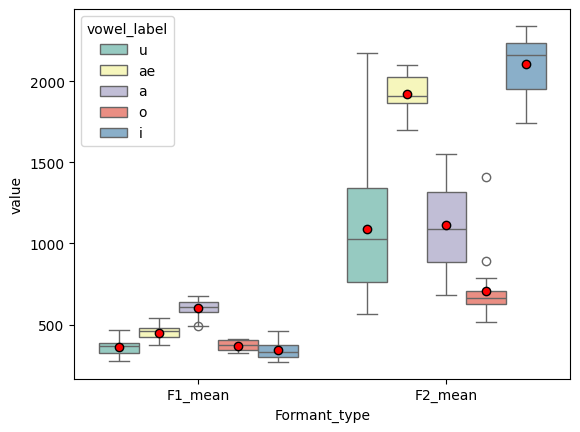

In [47]:
sns.boxplot(x='Formant_type',hue='vowel_label', y='value', data=pd.melt(model_formant_df, id_vars=['participant_id', 'file_id', 'word_label', 'vowel_label', 'gender'], value_vars=['F1_mean', 'F2_mean'], var_name='Formant_type', col_level=None, ignore_index=True), palette='Set3', showmeans=True, meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='red'))

In [106]:
#현재 41584개의 phone, 총 41600개의 phone이 검출되어야 함.
participant_formant_df

,participant_id,file_id,word_label,vowel_label,interval_number,start_time,end_time,duration,gender,success_rate,...,F4_min,F4_max,F4_count,F5_mean,F5_median,F5_std,F5_min,F5_max,F5_count,interval_key
0,44,LY044_stage4_20250509_1516.wav,baedsim,ae,3,3.222500,3.292500,0.070000,F,0.333333,...,3089.005746,4172.437683,4,4227.391271,4227.391271,30.238494,4197.152776,4257.629765,2,ae_3.2225
1,44,LY044_stage4_20250509_1516.wav,baedsim,i,6,3.572500,3.632500,0.060000,F,0.200000,...,4088.391434,4153.604215,2,NaN,NaN,NaN,NaN,NaN,0,i_3.5725
2,44,LY044_stage4_20250509_1516.wav,saeljjug,ae,10,5.042500,5.122500,0.080000,F,0.384615,...,4184.583936,4285.566993,5,NaN,NaN,NaN,NaN,NaN,0,ae_5.0425
3,44,LY044_stage4_20250509_1516.wav,saeljjug,u,13,5.422500,5.472500,0.050000,F,0.125000,...,3642.628288,3642.628288,1,4761.590994,4761.590994,0.000000,4761.590994,4761.590994,1,u_5.4225
4,44,LY044_stage4_20250509_1516.wav,pagun,a,17,6.732500,6.792500,0.060000,F,0.200000,...,4229.989416,4293.996870,2,NaN,NaN,NaN,NaN,NaN,0,a_6.7325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41579,31,31_stage5_20250411_1629.wav,noggag,a,912,235.452500,235.512385,0.059885,M,0.200000,...,3200.335809,3229.540645,2,3975.846669,3975.846669,46.274102,3929.572568,4022.120771,2,a_235.4525
41580,31,31_stage5_20250411_1629.wav,sojo,o,916,236.772624,236.842500,0.069876,M,0.333333,...,3165.521738,3198.852584,4,3852.320128,3873.020324,62.309485,3753.105532,3910.134333,4,o_236.7726
41581,31,31_stage5_20250411_1629.wav,sojo,o,918,236.932500,237.102196,0.169696,M,0.714286,...,3129.351938,3341.091963,20,4135.862245,4143.060474,73.706309,3960.563752,4286.350093,20,o_236.9325
41582,31,31_stage5_20250411_1629.wav,milsa,i,921,238.238044,238.317386,0.079341,M,0.384615,...,2924.015808,3001.321744,5,3684.459828,3688.928262,29.280946,3631.227237,3720.754782,5,i_238.2380


체크해야 할 것.
1. 개인 내애서 5종류의 phones, 개당 160회 검출되었는지
2. 개수가 맞다고 해도 단어별 모음 개수 카운팅이 제대로 되었는지 체크 필요.
3. 이상한 단어들이 있는지

In [116]:
# 참가자 별로 봤을 때에는 26번이 16개의 phone 누락.
pd.DataFrame(participant_formant_df['participant_id'].value_counts().reset_index().sort_values(by='participant_id', ascending=True)).reset_index().drop(columns=['index'])

,participant_id,count
0,2,800
1,4,800
2,5,800
3,6,800
4,7,800
5,8,800
6,9,800
7,10,800
8,11,800
9,13,800


In [128]:
# 최종적으로 정리.
# 실험 52명 중 데이터가 누수되어 버려진 건 2명(25, 58) / 25번은 여러 단어들이 누락. 58번은 중간에 필생? 을 성골? 이렇게 발음해버림,,
# 따라서 
excepted_p_id = [25, 58]
# 재 검토가 필요한 분절 파일들은 
# 11, 22, 26, 42, 45, 48, 50, 51, 52, 53, 54, 55, 61 인데 대부분 boundary fixation 문제. 
waiting_list = [11, 22, 26, 42, 45, 48, 50, 51, 52, 53, 54, 55, 61]
len(excepted_p_id) + len(waiting_list)

15

In [117]:
# 41600 / 50 = 832개 아닌 것들을 추출.
# 26번의 경우 누락된 단어들이 많아서, 
temp = participant_formant_df[['word_label', 'vowel_label']].groupby(['word_label']).count().reset_index()
temp = temp[temp['vowel_label'] != 832].reset_index().drop(columns=['index'])
temp.to_excel(os.path.join(exp_data_dir, 'participant_word_mis-aligned.xlsx'))
temp

,word_label,vowel_label
0,maebog,830
1,muun,830
2,paemul,830
3,pipog,830
4,pogab,830
5,siljog,830
6,songbu,830
7,suha,830


In [127]:
# 단어, 모음 레이블링 잘 됨.
participant_formant_df['word_label'].nunique(), participant_formant_df['vowel_label'].nunique()

(50, 5)

In [101]:
participant_formant_df[participant_formant_df['word_label'] == "sua"]#.to_excel(os.path.join(exp_data_dir, 'participant_formant_df_word_mis-aligned_maengo.xlsx'))

,participant_id,file_id,word_label,vowel_label,interval_number,start_time,end_time,duration,gender,success_rate,...,F4_min,F4_max,F4_count,F5_mean,F5_median,F5_std,F5_min,F5_max,F5_count,interval_key
414,44,LY044_stage6_20250509_1525.wav,sua,u,45,11.292500,11.432500,0.140000,F,0.652174,...,3760.837363,3943.244015,15,NaN,NaN,NaN,NaN,NaN,0,u_11.2925
415,44,LY044_stage6_20250509_1525.wav,sua,a,46,11.432500,11.732500,0.300000,F,0.836735,...,3047.031228,4923.042775,41,4632.912687,4568.511542,118.803833,4530.722428,4799.504090,3,a_11.4325
10968,34,034_stage4_20250416_1459.wav,sua,u,212,55.303902,55.399435,0.095533,M,0.500000,...,3296.957946,3346.991220,8,3939.802089,3944.037173,14.008568,3911.023920,3959.029614,8,u_55.3039
10969,34,034_stage4_20250416_1459.wav,sua,a,213,55.399435,55.610169,0.210734,M,0.764706,...,3460.024020,3817.341832,26,4058.024609,4055.510314,115.422857,3793.955080,4241.732199,25,a_55.3994


In [78]:
participant_formant_df[(participant_formant_df['participant_id'] == 4) & (participant_formant_df['word_label'] == 'suha')]

,participant_id,file_id,word_label,vowel_label,interval_number,start_time,end_time,duration,gender,success_rate,...,F4_min,F4_max,F4_count,F5_mean,F5_median,F5_std,F5_min,F5_max,F5_count,interval_key
16899,4,LY04_stage4_20250407_1535.wav,suha,u,306,96.544740,96.638871,0.094132,F,0.500000,...,3686.741384,3846.187047,8,4721.375367,4701.891379,84.271833,4629.294507,4832.940214,3,u_96.5447
16900,4,LY04_stage4_20250407_1535.wav,suha,a,308,96.731929,96.962476,0.230547,F,0.783784,...,3936.065808,4148.750677,29,4248.087285,4101.991983,268.014618,4076.493797,4711.871377,4,a_96.7319
17059,4,LY04_stage4_20250407_1535.wav,suha,u,792,228.176688,228.213301,0.036613,F,0.166667,...,3593.742004,3593.742004,1,4375.303442,4375.303442,0.000000,4375.303442,4375.303442,1,u_228.1767
17060,4,LY04_stage4_20250407_1535.wav,suha,a,794,228.371956,228.562648,0.190692,F,0.741935,...,3988.380377,4199.103960,23,NaN,NaN,NaN,NaN,NaN,0,a_228.3720
17104,4,LY04_stage6_20250407_1544.wav,suha,u,3,2.412500,2.608914,0.196414,F,0.750000,...,3574.082543,3935.405927,24,4507.401801,4554.896194,88.789792,4340.699536,4666.344325,20,u_2.4125
17105,4,LY04_stage6_20250407_1544.wav,suha,a,5,2.703497,2.946058,0.242560,F,0.794872,...,3063.061875,4081.473639,31,4096.355022,4083.269906,49.028019,4054.872882,4241.984351,25,a_2.7035
17300,4,LY04_stage2_20250407_1533.wav,suha,u,300,83.842500,84.000280,0.157780,F,0.692308,...,3643.047770,3979.028325,18,4656.060263,4664.415251,59.067286,4553.724294,4752.401041,12,u_83.8425
17301,4,LY04_stage2_20250407_1533.wav,suha,a,302,84.118509,84.313015,0.194506,F,0.750000,...,3943.361275,4199.213354,24,NaN,NaN,NaN,NaN,NaN,0,a_84.1185
17358,4,LY04_stage5_20250407_1540.wav,suha,u,168,51.905209,52.033277,0.128067,F,0.619048,...,3415.872851,3974.279048,13,4319.843317,4311.181565,131.405713,4160.794119,4585.452286,10,u_51.9052
17359,4,LY04_stage5_20250407_1540.wav,suha,a,170,52.096574,52.342500,0.245926,F,0.800000,...,2985.595781,4282.498157,32,4195.295353,4181.482601,71.317145,4117.470972,4400.942166,19,a_52.0966


In [118]:
# 2, 4, 9, 11, 19, 25
temp = participant_formant_df[['participant_id', 'word_label', 'vowel_label']].groupby(['participant_id', 'vowel_label']).count().reset_index()
temp[temp['word_label'] != 160].reset_index().drop(columns=['index'])

,participant_id,vowel_label,word_label
0,25,a,158
1,25,ae,158
2,25,i,158
3,25,o,155
4,25,u,155


In [ ]:
# 25 번만 문제
temp = participant_formant_df[['participant_id', 'word_label', 'vowel_label']].groupby(['participant_id', 'word_label']).count().reset_index()
temp[temp['vowel_label'] != 16]
#temp

,participant_id,word_label,vowel_label
910,25,maebog,14
919,25,muun,14
930,25,paemul,14
935,25,pipog,14
936,25,pogab,14
944,25,siljog,14
947,25,songbu,14
948,25,suha,14


In [56]:
participant_formant_df[(participant_formant_df['participant_id'] == 2) & (participant_formant_df['word_label'] == 'suaha')]

,participant_id,file_id,word_label,vowel_label,interval_number,start_time,end_time,duration,gender,success_rate,...,F4_min,F4_max,F4_count,F5_mean,F5_median,F5_std,F5_min,F5_max,F5_count,interval_key
12837,2,02_stage6_20250404_1401.wav,suaha,u,121,22.231461,22.316473,0.085011,F,0.428571,...,3635.741897,3732.698840,6,4705.871120,4703.446517,49.735179,4647.646348,4792.493442,5,u_22.2315
12838,2,02_stage6_20250404_1401.wav,suaha,a,122,22.316473,22.317485,0.001012,F,1.000000,...,4096.802179,4096.802179,1,NaN,NaN,NaN,NaN,NaN,0,a_22.3165
12839,2,02_stage6_20250404_1401.wav,suaha,a,124,22.344810,22.520905,0.176095,F,0.724138,...,3859.085580,4172.425233,21,4538.838458,4538.838458,0.000000,4538.838458,4538.838458,1,a_22.3448
13034,2,02_stage5_20250404_1357.wav,suaha,u,108,33.275101,33.354429,0.079328,F,0.384615,...,3596.476173,3665.788215,5,4665.647714,4673.734904,48.468900,4599.213469,4723.610436,5,u_33.2751
13035,2,02_stage5_20250404_1357.wav,suaha,a,109,33.354429,33.357480,0.003051,F,1.000000,...,3690.232026,3690.232026,1,NaN,NaN,NaN,NaN,NaN,0,a_33.3544
13036,2,02_stage5_20250404_1357.wav,suaha,a,111,33.404772,33.592413,0.187641,F,0.741935,...,3789.856272,3886.031504,23,4792.185255,4798.249915,48.207498,4705.610668,4852.925237,5,a_33.4048


In [ ]:
#participant_formant_df.groupby(['participant_id', 'word_label', 'vowel_label']).count().reset_index()[['participant_id', 'word_label', 'vowel_label', 'file_id']].to_excel(os.path.join(exp_data_dir, 'participant_formant_df_word_count.xlsx'))

In [53]:
participant_formant_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38388 entries, 0 to 38387
Data columns (total 41 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   participant_id   38388 non-null  int64  
 1   file_id          38388 non-null  object 
 2   word_label       38388 non-null  object 
 3   vowel_label      38388 non-null  object 
 4   interval_number  38388 non-null  int64  
 5   start_time       38388 non-null  float64
 6   end_time         38388 non-null  float64
 7   duration         38388 non-null  float64
 8   gender           38388 non-null  object 
 9   success_rate     38388 non-null  float64
 10  F1_mean          38387 non-null  float64
 11  F1_median        38387 non-null  float64
 12  F1_std           38387 non-null  float64
 13  F1_min           38387 non-null  float64
 14  F1_max           38387 non-null  float64
 15  F1_count         38388 non-null  int64  
 16  F2_mean          38387 non-null  float64
 17  F2_median   

현재 분석 제외대상은 drop

In [12]:
analyzed_p_df = participant_formant_df[~participant_formant_df['participant_id'].isin(excepted_p_id)].reset_index(drop=True)
analyzed_p_df.drop(columns=['F3_mean', 'F3_median', 'F3_std', 'F3_min', 'F3_max',
       'F3_count', 'F4_mean', 'F4_median', 'F4_std', 'F4_min', 'F4_max',
       'F4_count', 'F5_mean', 'F5_median', 'F5_std', 'F5_min', 'F5_max',
       'F5_count'], inplace=True)
analyzed_p_df

,participant_id,file_id,word_label,vowel_label,interval_number,start_time,end_time,duration,gender,success_rate,...,F1_min,F1_max,F1_count,F2_mean,F2_median,F2_std,F2_min,F2_max,F2_count,interval_key
0,44,LY044_stage4_20250509_1516.wav,baedsim,ae,3,3.222500,3.292500,0.070000,F,0.333333,...,200.204444,654.799993,4,1477.530061,1521.709406,687.784885,702.006912,2164.694521,4,ae_3.2225
1,44,LY044_stage4_20250509_1516.wav,baedsim,i,6,3.572500,3.632500,0.060000,F,0.200000,...,397.838649,406.594279,2,2249.730218,2249.730218,39.800559,2209.929659,2289.530777,2,i_3.5725
2,44,LY044_stage4_20250509_1516.wav,saeljjug,ae,10,5.042500,5.122500,0.080000,F,0.384615,...,729.518330,854.376893,5,2129.038536,2146.166640,42.758696,2070.905945,2173.695276,5,ae_5.0425
3,44,LY044_stage4_20250509_1516.wav,saeljjug,u,13,5.422500,5.472500,0.050000,F,0.125000,...,452.165926,452.165926,1,1332.625004,1332.625004,0.000000,1332.625004,1332.625004,1,u_5.4225
4,44,LY044_stage4_20250509_1516.wav,pagun,a,17,6.732500,6.792500,0.060000,F,0.200000,...,942.284862,986.660849,2,1530.222699,1530.222699,1.637259,1528.585440,1531.859958,2,a_6.7325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36795,31,31_stage5_20250411_1629.wav,noggag,a,912,235.452500,235.512385,0.059885,M,0.200000,...,717.480367,729.919898,2,1170.136887,1170.136887,3.783081,1166.353806,1173.919968,2,a_235.4525
36796,31,31_stage5_20250411_1629.wav,sojo,o,916,236.772624,236.842500,0.069876,M,0.333333,...,412.836348,422.022455,4,968.555184,959.179292,45.929326,919.233544,1036.628609,4,o_236.7726
36797,31,31_stage5_20250411_1629.wav,sojo,o,918,236.932500,237.102196,0.169696,M,0.714286,...,418.632961,503.855696,20,809.972842,768.095206,83.640646,732.032539,1025.845566,20,o_236.9325
36798,31,31_stage5_20250411_1629.wav,milsa,i,921,238.238044,238.317386,0.079341,M,0.384615,...,326.111491,344.462479,5,1711.616584,1710.708575,3.552281,1706.752862,1716.851406,5,i_238.2380


In [13]:
analyzed_p_df['stage'] = analyzed_p_df['file_id'].str.split('_').str[1]
analyzed_p_df

,participant_id,file_id,word_label,vowel_label,interval_number,start_time,end_time,duration,gender,success_rate,...,F1_max,F1_count,F2_mean,F2_median,F2_std,F2_min,F2_max,F2_count,interval_key,stage
0,44,LY044_stage4_20250509_1516.wav,baedsim,ae,3,3.222500,3.292500,0.070000,F,0.333333,...,654.799993,4,1477.530061,1521.709406,687.784885,702.006912,2164.694521,4,ae_3.2225,stage4
1,44,LY044_stage4_20250509_1516.wav,baedsim,i,6,3.572500,3.632500,0.060000,F,0.200000,...,406.594279,2,2249.730218,2249.730218,39.800559,2209.929659,2289.530777,2,i_3.5725,stage4
2,44,LY044_stage4_20250509_1516.wav,saeljjug,ae,10,5.042500,5.122500,0.080000,F,0.384615,...,854.376893,5,2129.038536,2146.166640,42.758696,2070.905945,2173.695276,5,ae_5.0425,stage4
3,44,LY044_stage4_20250509_1516.wav,saeljjug,u,13,5.422500,5.472500,0.050000,F,0.125000,...,452.165926,1,1332.625004,1332.625004,0.000000,1332.625004,1332.625004,1,u_5.4225,stage4
4,44,LY044_stage4_20250509_1516.wav,pagun,a,17,6.732500,6.792500,0.060000,F,0.200000,...,986.660849,2,1530.222699,1530.222699,1.637259,1528.585440,1531.859958,2,a_6.7325,stage4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36795,31,31_stage5_20250411_1629.wav,noggag,a,912,235.452500,235.512385,0.059885,M,0.200000,...,729.919898,2,1170.136887,1170.136887,3.783081,1166.353806,1173.919968,2,a_235.4525,stage5
36796,31,31_stage5_20250411_1629.wav,sojo,o,916,236.772624,236.842500,0.069876,M,0.333333,...,422.022455,4,968.555184,959.179292,45.929326,919.233544,1036.628609,4,o_236.7726,stage5
36797,31,31_stage5_20250411_1629.wav,sojo,o,918,236.932500,237.102196,0.169696,M,0.714286,...,503.855696,20,809.972842,768.095206,83.640646,732.032539,1025.845566,20,o_236.9325,stage5
36798,31,31_stage5_20250411_1629.wav,milsa,i,921,238.238044,238.317386,0.079341,M,0.384615,...,344.462479,5,1711.616584,1710.708575,3.552281,1706.752862,1716.851406,5,i_238.2380,stage5


In [107]:
analyzed_p_df.drop('file_id', axis=1, inplace=True)

In [110]:
pd.DataFrame(analyzed_p_df.groupby(['participant_id', 'vowel_label', 'stage'])['F1_mean'].mean())

F1_mean
participant_id vowel_label stage             
5              a           stage2  704.649587
                           stage4  722.487660
                           stage5  718.806936
                           stage6  785.318288
               ae          stage2  531.198978
...                                       ...
62             o           stage6  371.380676
               u           stage2  388.438098
                           stage4  415.594920
                           stage5  409.074125
                           stage6  370.612485

[920 rows x 1 columns]

In [ ]:
pd.DataFrame(analyzed_p_df.groupby(['participant_id', 'vowel_label', 'stage'])['F2_mean'].mean())

F2_mean
participant_id vowel_label stage              
5              a           stage2  1284.262970
                           stage4  1279.703994
                           stage5  1269.972752
                           stage6  1328.735049
               ae          stage2  1965.421661
...                                        ...
62             o           stage6   856.210827
               u           stage2  1177.758250
                           stage4  1311.664465
                           stage5  1266.782423
                           stage6  1203.969012

[920 rows x 1 columns]

In [140]:
# 1단계: F1_mean을 groupby로 계산하고 DataFrame으로 변환
f1_df = analyzed_p_df.groupby(['participant_id', 'vowel_label', 'stage'])['F1_mean'].mean().reset_index()
f1_df = f1_df.rename(columns={'F1_mean': 'F1_mean'})

# 2단계: F2_mean을 groupby로 계산하고 DataFrame으로 변환  
f2_df = analyzed_p_df.groupby(['participant_id', 'vowel_label', 'stage'])['F2_mean'].mean().reset_index()
f2_df = f2_df.rename(columns={'F2_mean': 'F2_mean'})

# 3단계: 두 DataFrame을 merge
p_formant_stage_df = pd.merge(f1_df, f2_df, on=['participant_id', 'vowel_label', 'stage'], how='inner')
p_formant_stage_df.to_excel('formant_results_all_vowels_participant_stage.xlsx')
p_formant_stage_df

,participant_id,vowel_label,stage,F1_mean,F2_mean
0,5,a,stage2,704.649587,1284.262970
1,5,a,stage4,722.487660,1279.703994
2,5,a,stage5,718.806936,1269.972752
3,5,a,stage6,785.318288,1328.735049
4,5,ae,stage2,531.198978,1965.421661
...,...,...,...,...,...
915,62,o,stage6,371.380676,856.210827
916,62,u,stage2,388.438098,1177.758250
917,62,u,stage4,415.594920,1311.664465
918,62,u,stage5,409.074125,1266.782423


In [121]:
model_formant_standard_df

,vowel_label,F1_mean,F2_mean
0,a,599.975256,1111.359312
1,ae,450.373788,1918.021890
2,i,342.885760,2104.076762
3,o,370.757324,704.097738
4,u,361.505695,1086.596290


In [145]:
model_formant_standard_df.to_excel('formant_results_all_vowels_model_standard.xlsx')

<Axes: xlabel='F2_mean', ylabel='F1_mean'>

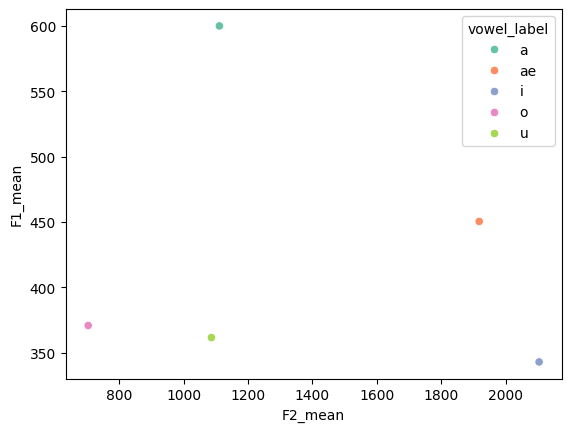

In [131]:
# Model standard
model_formant_standard_df.columns

sns.scatterplot(y='F1_mean', x='F2_mean', data=model_formant_standard_df, hue='vowel_label', palette='Set2', alpha=1.0)


# Participant standard

#sns.scatterplot(y='F1_mean', x='F2_mean', data=p_formant_stage_df, hue='vowel_label', palette='Set2', alpha=1.0)


<Axes: xlabel='F2_mean', ylabel='F1_mean'>

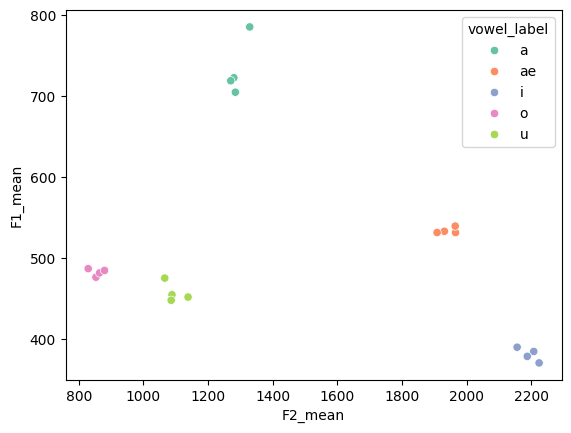

In [143]:
sns.scatterplot(y='F1_mean', x='F2_mean', data=p_formant_stage_df[p_formant_stage_df['participant_id'] == 5], hue='vowel_label', palette='Set2', alpha=1.0)